In [1]:
import numpy as np
import pandas as pd
from scipy.stats import kruskal, mannwhitneyu

for _name, _type in {"float": float, "int": int, "bool": bool, "object": object}.items():
    if not hasattr(np, _name):
        setattr(np, _name, _type)
from openpyxl import load_workbook

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
sns.set_theme(style="white", context="notebook")
plt.rcParams["svg.fonttype"] = "none"

META_FILE = "../pre-calculated_data/supp1_sample_metadata.xlsx"
MAG_FILE = "../pre-calculated_data/supp3_MAG_info.csv"
BGC_FILE = "../pre-calculated_data/supp7_BGC.csv"


c:\Users\admin\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
<ipython-input-1-7e8aa29e4f47>:6: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, _name):
<ipython-input-1-7e8aa29e4f47>:6: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, _name):


In [4]:
def read_first_excel_sheet(path):
    workbook = load_workbook(path, read_only=True, data_only=True)
    sheet = workbook[workbook.sheetnames[0]]
    rows = list(sheet.iter_rows(values_only=True))
    return pd.DataFrame(rows[1:], columns=rows[0])

def month_label(value):
    text = str(value).strip()
    for fmt in ("%m-%d-%Y", "%m-%Y", "%Y-%m-%d", "%Y-%m"):
        try:
            return pd.to_datetime(text, format=fmt).strftime("%Y-%m")
        except ValueError:
            pass
    return pd.to_datetime(text).strftime("%Y-%m")

meta = read_first_excel_sheet(META_FILE)
mag = pd.read_csv(MAG_FILE)
bgc = pd.read_csv(BGC_FILE)

required_meta = {"Sample_id", "City", "Location", "Date"}
required_mag = {"Sample", "Mag ID", "GTDB", "Quality"}
required_bgc = {"BGC_region", "Category", "MAG", "Taxonomy", "Family"}

meta["Sample_id"] = meta["Sample_id"].astype(str).str.strip()
meta["Time"] = meta["Date"].map(month_label)
mag["Sample"] = mag["Sample"].astype(str).str.strip()

bgc_annotated = bgc.merge(
    mag[["Mag ID", "Sample", "GTDB"]],
    left_on="MAG", right_on="Mag ID", how="left", validate="many_to_one",
)
taxonomy_agreement = (
    bgc_annotated["Taxonomy"].fillna("").eq(bgc_annotated["GTDB"].fillna(""))
).mean()


In [5]:
mag_counts = mag.groupby("Sample").size().rename("MAGs")
bgc_counts = (
    bgc_annotated.groupby("Sample")
    .agg(BGCs=("BGC_region", "size"), GCFs=("Family", "nunique"))
)
sample_metrics = (
    meta.merge(
        pd.concat([mag_counts, bgc_counts], axis=1).fillna(0).reset_index(),
        left_on="Sample_id", right_on="Sample", how="left", validate="one_to_one",
    )
)
sample_metrics["BGCs_per_MAG"] = sample_metrics["BGCs"] / sample_metrics["MAGs"]
sample_metrics["GCFs_per_MAG"] = sample_metrics["GCFs"] / sample_metrics["MAGs"]

metric_cols = ["BGCs_per_MAG", "GCFs_per_MAG"]
metric_labels = {
    "BGCs_per_MAG": "BGCs per MAG",
    "GCFs_per_MAG": "GCFs per MAG",
}

city_cmp = sample_metrics.assign(
    Analysis="Different cities", Stratum="All cities", Group=sample_metrics["City"]
)
location_cmp = sample_metrics.assign(
    Analysis="Locations within city", Stratum=sample_metrics["City"], Group=sample_metrics["Location"]
)

time_parts = []
nanjing_time = sample_metrics.loc[sample_metrics["City"].eq("Nanjing")].copy()
if nanjing_time["Time"].nunique() > 1:
    time_parts.append(
        nanjing_time.assign(
            Analysis="Times within location",
            Stratum="Nanjing | All locations",
            Group=nanjing_time["Time"],
        )
    )
other_time = sample_metrics.loc[~sample_metrics["City"].eq("Nanjing")].copy()
for (city, location), frame in other_time.groupby(["City", "Location"], observed=True, sort=False):
    if frame["Time"].nunique() > 1:
        time_parts.append(
            frame.assign(
                Analysis="Times within location",
                Stratum=f"{city} | {location}",
                Group=frame["Time"],
            )
        )
time_cmp = pd.concat(time_parts, ignore_index=True)
comparison_data = pd.concat([city_cmp, location_cmp, time_cmp], ignore_index=True)

def bonferroni_adjust(p_values):
    p = np.asarray(p_values, dtype=float)
    return np.clip(p * len(p), 0, 1)

def run_tests(data):
    records = []
    for (analysis, stratum), frame in data.groupby(["Analysis", "Stratum"], observed=True, sort=False):
        groups = list(frame["Group"].dropna().unique())
        if len(groups) < 2:
            continue
        for metric in metric_cols:
            arrays = [frame.loc[frame["Group"].eq(group), metric].dropna().to_numpy() for group in groups]
            if len(groups) == 2:
                statistic, p_value = mannwhitneyu(arrays[0], arrays[1], alternative="two-sided")
                test = "Mann-Whitney U"
            else:
                statistic, p_value = kruskal(*arrays)
                test = "Kruskal-Wallis"
            medians = "; ".join(
                f"{group}: n={len(values)}, median={np.median(values):.3f}"
                for group, values in zip(groups, arrays)
            )
            records.append({
                "Analysis": analysis, "Stratum": stratum, "Metric": metric,
                "Test": test, "Statistic": statistic, "p_value": p_value,
                "Groups_and_medians": medians,
            })
    result = pd.DataFrame(records)
    result["q_value"] = result.groupby("Analysis")["p_value"].transform(
        lambda x: bonferroni_adjust(x.to_numpy())
    )
    return result.sort_values(["Analysis", "Stratum", "Metric"]).reset_index(drop=True)

tests = run_tests(comparison_data)
descriptive = (
    comparison_data.groupby(["Analysis", "Stratum", "Group"], observed=True)[metric_cols]
    .agg(["count", "median", "mean", "std", "min", "max"])
)
descriptive.columns = ["__".join(column) for column in descriptive.columns]
descriptive = descriptive.reset_index()
display(tests)


,Analysis,Stratum,Metric,Test,Statistic,p_value,Groups_and_medians,q_value
0,Different cities,All cities,BGCs_per_MAG,Mann-Whitney U,260.000000,0.013067,"Shanghai: n=30, median=3.766; Nanjing: n=28, m...",0.026133
1,Different cities,All cities,GCFs_per_MAG,Mann-Whitney U,262.500000,0.014564,"Shanghai: n=30, median=3.739; Nanjing: n=28, m...",0.029128
2,Locations within city,Nanjing,BGCs_per_MAG,Mann-Whitney U,47.000000,0.099062,"Nanjing Agricultural University: n=8, median=3...",0.396249
3,Locations within city,Nanjing,GCFs_per_MAG,Mann-Whitney U,49.000000,0.122557,"Nanjing Agricultural University: n=8, median=3...",0.490228
4,Locations within city,Shanghai,BGCs_per_MAG,Kruskal-Wallis,2.310908,0.510434,"Fudan University: n=9, median=3.941; GongQing ...",1.000000
5,Locations within city,Shanghai,GCFs_per_MAG,Kruskal-Wallis,3.229749,0.357541,"Fudan University: n=9, median=3.909; GongQing ...",1.000000
6,Times within location,Nanjing | All locations,BGCs_per_MAG,Mann-Whitney U,93.000000,0.836194,"2023-05: n=14, median=4.137; 2023-08: n=14, me...",1.000000
7,Times within location,Nanjing | All locations,GCFs_per_MAG,Mann-Whitney U,94.000000,0.872238,"2023-05: n=14, median=4.069; 2023-08: n=14, me...",1.000000
8,Times within location,Shanghai | Fudan University,BGCs_per_MAG,Mann-Whitney U,16.000000,0.190476,"2023-05: n=5, median=4.020; 2023-07: n=4, medi...",0.761905
9,Times within location,Shanghai | Fudan University,GCFs_per_MAG,Mann-Whitney U,16.000000,0.190476,"2023-05: n=5, median=3.973; 2023-07: n=4, medi...",0.761905


<ipython-input-7-dccf061b55e0>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
<ipython-input-7-dccf061b55e0>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


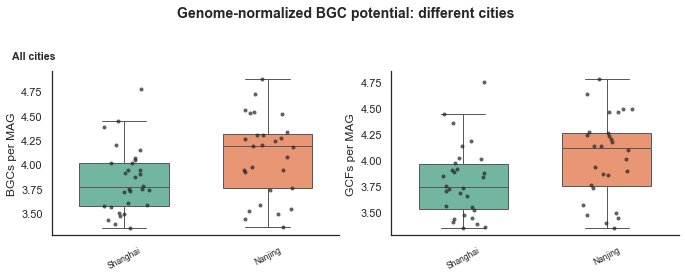

<ipython-input-7-dccf061b55e0>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
<ipython-input-7-dccf061b55e0>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
<ipython-input-7-dccf061b55e0>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
<ipython-input-7-dccf061b55e0>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


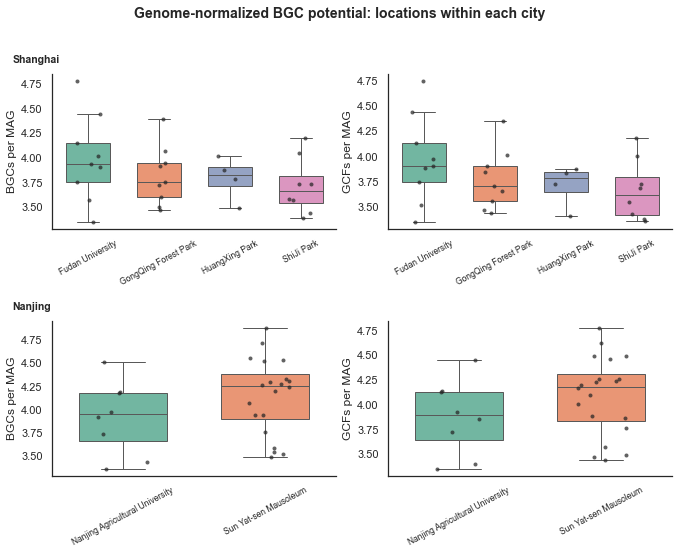

<ipython-input-7-dccf061b55e0>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
<ipython-input-7-dccf061b55e0>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
<ipython-input-7-dccf061b55e0>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
<ipython-input-7-dccf061b55e0>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


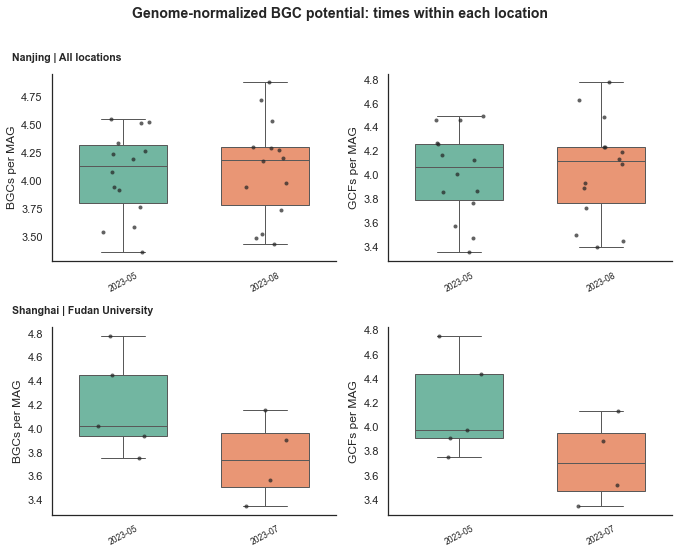

In [7]:
def plot_comparison(data, strata, filename, title):
    fig, axes = plt.subplots(
        len(strata), len(metric_cols),
        figsize=(4.8 * len(metric_cols), 3.8 * len(strata)),
        squeeze=False,
    )
    palette = sns.color_palette("Set2", n_colors=max(4, data["Group"].nunique()))
    for row, stratum in enumerate(strata):
        subset = data.loc[data["Stratum"].eq(stratum)]
        order = list(subset["Group"].drop_duplicates())
        for col, metric in enumerate(metric_cols):
            ax = axes[row, col]
            sns.boxplot(
                data=subset, x="Group", y=metric, order=order, ax=ax,
                palette=palette[:len(order)], width=0.62, showfliers=False,
            )
            sns.stripplot(
                data=subset, x="Group", y=metric, order=order, ax=ax,
                color="#252525", alpha=0.72, size=4, jitter=0.18,
            )
            ax.set_xlabel("")
            ax.set_ylabel(metric_labels[metric])
            ax.tick_params(axis="x", rotation=28, labelsize=8.5)
            ax.grid(False)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            if col == 0:
                ax.text(
                    -0.14, 1.06, stratum, transform=ax.transAxes,
                    ha="left", va="bottom", fontsize=10.5, fontweight="bold",
                )
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.show()

plot_comparison(
    city_cmp, ["All cities"], "01_BGC_GCF_different_cities",
    "Genome-normalized BGC potential: different cities",
)
plot_comparison(
    location_cmp, list(location_cmp["Stratum"].drop_duplicates()),
    "02_BGC_GCF_locations_within_city",
    "Genome-normalized BGC potential: locations within each city",
)
plot_comparison(
    time_cmp, list(time_cmp["Stratum"].drop_duplicates()),
    "03_BGC_GCF_times_within_location",
    "Genome-normalized BGC potential: times within each location",
)


In [8]:
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage
from scipy.linalg import eigh
from scipy.stats import rankdata

sample_order = meta["Sample_id"].tolist()
gcf_presence = (
    pd.crosstab(bgc_annotated["Sample"], bgc_annotated["Family"])
    .gt(0).astype(int)
    .reindex(sample_order, fill_value=0)
)

jaccard_condensed = pdist(gcf_presence.to_numpy(dtype=bool), metric="jaccard")
jaccard_matrix = squareform(jaccard_condensed)
jaccard_df = pd.DataFrame(jaccard_matrix, index=sample_order, columns=sample_order)
average_linkage = linkage(jaccard_condensed, method="average")


In [10]:
def classical_pcoa(distance_matrix):
    n = distance_matrix.shape[0]
    centering = np.eye(n) - np.ones((n, n)) / n
    gram = -0.5 * centering @ (distance_matrix ** 2) @ centering
    eigenvalues, eigenvectors = eigh(gram)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    positive = eigenvalues > 1e-12
    positive_values = eigenvalues[positive]
    coordinates = eigenvectors[:, positive] * np.sqrt(positive_values)
    explained = positive_values / positive_values.sum()
    return coordinates, positive_values, explained

def anosim_test(distance_matrix, labels, permutations=9_999, seed=20260701):
    labels = np.asarray(labels)
    n = len(labels)
    upper = np.triu_indices(n, k=1)
    ranked = rankdata(distance_matrix[upper], method="average")
    same = labels[upper[0]] == labels[upper[1]]
    if same.all() or (~same).all():
        raise ValueError("ANOSIM requires within- and between-group distances.")
    divisor = n * (n - 1) / 4
    observed = (ranked[~same].mean() - ranked[same].mean()) / divisor
    rng = np.random.default_rng(seed)
    permuted = np.empty(permutations)
    for i in range(permutations):
        shuffled = rng.permutation(labels)
        perm_same = shuffled[upper[0]] == shuffled[upper[1]]
        permuted[i] = (
            ranked[~perm_same].mean() - ranked[perm_same].mean()
        ) / divisor
    p_value = (np.count_nonzero(permuted >= observed) + 1) / (permutations + 1)
    return observed, p_value

pcoa_coordinates, pcoa_eigenvalues, pcoa_explained = classical_pcoa(jaccard_matrix)
gcf_pcoa = pd.DataFrame(
    pcoa_coordinates[:, :2], index=sample_order, columns=["PCoA1", "PCoA2"]
).reset_index().rename(columns={"index": "Sample_id"})
gcf_pcoa = gcf_pcoa.merge(
    meta[["Sample_id", "City", "Location", "Time"]],
    on="Sample_id", how="left", validate="one_to_one",
)

anosim_records = []
score_meta = gcf_pcoa.set_index("Sample_id").loc[sample_order].reset_index()

def add_anosim(comparison, stratum, indices, labels):
    indices = np.asarray(indices)
    subset = jaccard_matrix[np.ix_(indices, indices)]
    statistic, p_value = anosim_test(subset, labels)
    anosim_records.append({
        "Comparison": comparison, "Stratum": stratum,
        "Groups": len(pd.unique(labels)), "n_samples": len(labels),
        "R": statistic, "p_value": p_value, "Permutations": 9_999,
    })

all_indices = np.arange(len(score_meta))
add_anosim("City", "All samples", all_indices, score_meta["City"].to_numpy())
add_anosim(
    "Location-time", "All samples", all_indices,
    (score_meta["Location"] + " | " + score_meta["Time"]).to_numpy(),
)
for city, frame in score_meta.groupby("City", sort=False):
    if frame["Location"].nunique() > 1:
        add_anosim(
            "Location within city", city, frame.index.to_numpy(),
            frame["Location"].to_numpy(),
        )
for (city, location), frame in score_meta.groupby(["City", "Location"], sort=False):
    if frame["Time"].nunique() > 1:
        add_anosim(
            "Time within location", f"{city} | {location}",
            frame.index.to_numpy(), frame["Time"].to_numpy(),
        )

gcf_anosim = pd.DataFrame(anosim_records)
display(gcf_anosim)
print(f"PCoA1: {pcoa_explained[0] * 100:.2f}%; PCoA2: {pcoa_explained[1] * 100:.2f}%")


,Comparison,Stratum,Groups,n_samples,R,p_value,Permutations
0,City,All samples,2,58,0.530185,0.0001,9999
1,Location-time,All samples,9,58,0.451169,0.0001,9999
2,Location within city,Shanghai,4,30,0.155531,0.0053,9999
3,Location within city,Nanjing,2,28,0.430591,0.0008,9999
4,Time within location,Shanghai | Fudan University,2,9,-0.037500,0.5253,9999
5,Time within location,Nanjing | Nanjing Agricultural University,2,8,-0.104167,0.7150,9999
6,Time within location,Nanjing | Sun Yat-sen Mausoleum,2,20,0.031333,0.2446,9999


PCoA1: 5.36%; PCoA2: 3.68%


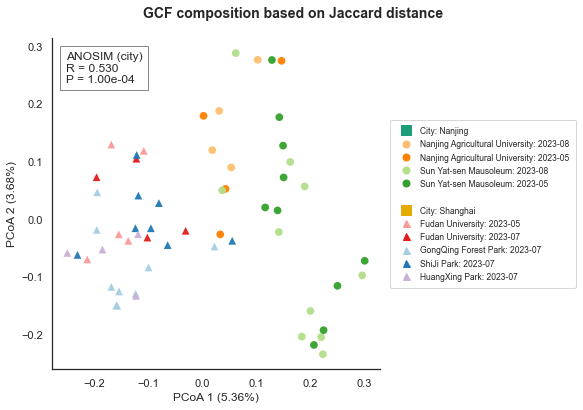

In [12]:
group_style = [
    ("Nanjing", "Nanjing Agricultural University", "2023-08", "#fdbf6f"),
    ("Nanjing", "Nanjing Agricultural University", "2023-05", "#ff7f00"),
    ("Nanjing", "Sun Yat-sen Mausoleum", "2023-08", "#b2df8a"),
    ("Nanjing", "Sun Yat-sen Mausoleum", "2023-05", "#33a02c"),
    ("Shanghai", "Fudan University", "2023-05", "#fb9a99"),
    ("Shanghai", "Fudan University", "2023-07", "#e31a1c"),
    ("Shanghai", "GongQing Forest Park", "2023-07", "#a6cee3"),
    ("Shanghai", "ShiJi Park", "2023-07", "#1f78b4"),
    ("Shanghai", "HuangXing Park", "2023-07", "#cab2d6"),
]
city_markers = {"Nanjing": "o", "Shanghai": "^"}
city_header_colors = {"Nanjing": "#1b9e77", "Shanghai": "#e6ab02"}

fig, ax = plt.subplots(figsize=(8.3, 5.8))
legend_handles = []
current_city = None
for city, location, time, color in group_style:
    if city != current_city:
        if current_city is not None:
            legend_handles.append(Line2D([], [], linestyle="none", label=" "))
        legend_handles.append(
            Line2D(
                [], [], marker="s", linestyle="none", markersize=10,
                markerfacecolor=city_header_colors[city],
                markeredgecolor=city_header_colors[city],
                label=f"City: {city}",
            )
        )
        current_city = city
    subset = gcf_pcoa.loc[
        gcf_pcoa["City"].eq(city)
        & gcf_pcoa["Location"].eq(location)
        & gcf_pcoa["Time"].eq(time)
    ]
    marker_symbol = city_markers[city]
    ax.scatter(
        subset["PCoA1"], subset["PCoA2"], color=color,
        marker=marker_symbol, s=60, edgecolor="none", alpha=0.95,
    )
    legend_handles.append(
        Line2D(
            [], [], marker=marker_symbol, linestyle="none", markersize=7,
            markerfacecolor=color, markeredgecolor=color,
            label=f"{location}: {time}",
        )
    )

city_result = gcf_anosim.loc[gcf_anosim["Comparison"].eq("City")].iloc[0]
p_text = f"{city_result.p_value:.2e}" if city_result.p_value < 0.001 else f"{city_result.p_value:.3f}"
ax.text(
    0.04, 0.96,
    f"ANOSIM (city)\nR = {city_result.R:.3f}\nP = {p_text}",
    transform=ax.transAxes, ha="left", va="top",
    bbox={"facecolor": "white", "edgecolor": "#888888", "boxstyle": "square,pad=0.45"},
)
ax.set_xlabel(f"PCoA 1 ({pcoa_explained[0] * 100:.2f}%)")
ax.set_ylabel(f"PCoA 2 ({pcoa_explained[1] * 100:.2f}%)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
ax.legend(
    handles=legend_handles, loc="center left", bbox_to_anchor=(1.02, 0.5),
    frameon=True, fontsize=8.5, handletextpad=0.7, borderpad=0.8,
)
fig.suptitle("GCF composition based on Jaccard distance", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()
